In [4]:
import seaborn as sns
import pandas as pd
# Load Titanic dataset
titanic = pd.read_csv("datasets/Titanic-Dataset.csv")

# Inspect first 5 rows
print(titanic.head())
print(titanic.describe())
print(titanic.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [27]:
titanic.skew(numeric_only=True)

survived      0.478523
pclass       -0.630548
age           0.389108
sibsp         3.695352
parch         2.749117
fare          4.787317
adult_male   -0.420431
alone        -0.420431
dtype: float64

In [31]:
print(titanic.isnull().sum().to_string())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0


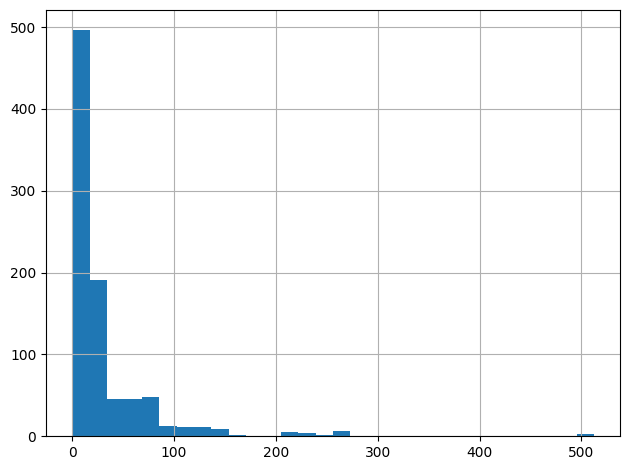

In [29]:
import matplotlib.pyplot as plt

titanic["fare"].hist(bins=30)
plt.show()


In [6]:
import matplotlib.pyplot as plt

plt.rcParams["figure.autolayout"] = True


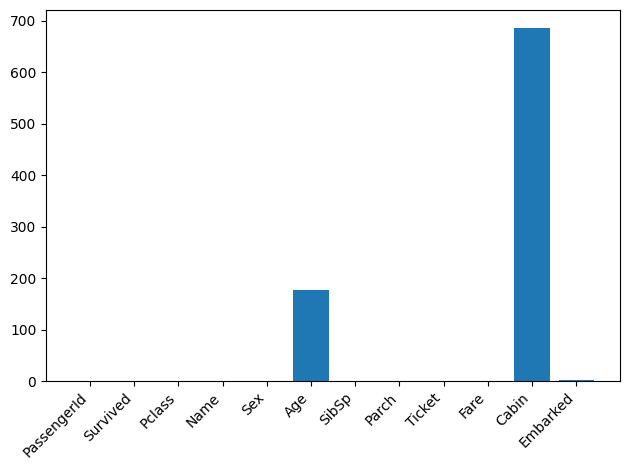

In [7]:
# fig, ax = plt.subplots(constrained_layout=True)
plt.bar(titanic.isnull().sum().index, titanic.isnull().sum().values)
plt.xticks(rotation=45, ha="right")
plt.show()
# plt.tight_layout()

In [7]:
numeric_cols = titanic.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()
corr_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [ ]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

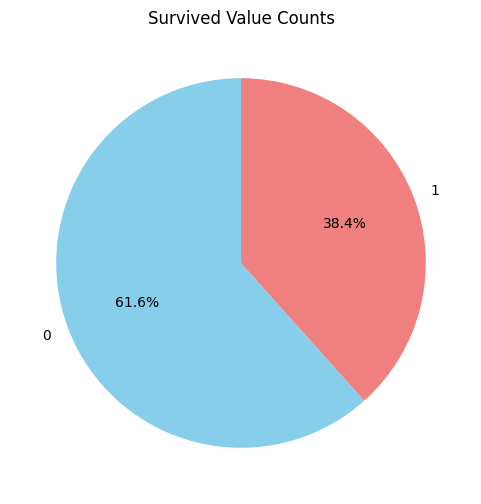

In [7]:
import matplotlib.pyplot as plt

# Count the values in the label column
value_counts = titanic['survived'].value_counts()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title("Survived Value Counts")

# Save the chart to a file
plt.savefig("survived_pie_chart.png")

# Optional: Show the chart
plt.show()


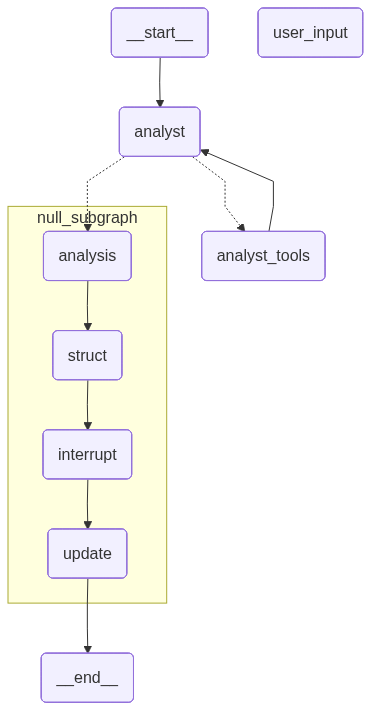

In [12]:

from analyst.nodes import analyst_call
from preprocessor.config.null_handler import null_handler_config
from preprocessor.nodes import preprocessor_call
from state import should_continue, MessagesState, make_tool_node, ask_user_node, preprocessor_should_continue
from langgraph.graph import StateGraph, START, END
from analyst.tools import tools_by_name as analyst_tools
from langgraph.checkpoint.memory import InMemorySaver
import uuid



# Build workflow
agent_builder = StateGraph(MessagesState)
analyst_tool_node = make_tool_node(analyst_tools)
null_subgraph = build_preprocessor_subgraph(null_handler_config)
# Add nodes
agent_builder.add_node("analyst", analyst_call)
agent_builder.add_node("analyst_tools", analyst_tool_node)
agent_builder.add_node("user_input",ask_user_node)
agent_builder.add_node("null_subgraph", null_subgraph)


# Add edges to connect nodes
agent_builder.add_edge(START, "analyst")
agent_builder.add_conditional_edges(
    "analyst",
    should_continue,
    ["analyst_tools", "null_subgraph"]
)
agent_builder.add_edge("analyst_tools", "analyst")


# Compile the agent
checkpointer = InMemorySaver()
agent = agent_builder.compile(checkpointer=checkpointer)

config = {
    "configurable": {
        "thread_id": "chat-1",
    }
}


# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))




[analyst]
Tool calls: [{'name': 'analyse_data', 'args': {'data': 'datasets/Titanic-Dataset.csv'}, 'id': '5e8eeb96-fd77-4402-9488-a3ee1b375589', 'type': 'tool_call'}]

[analyst_tools]
Content:    PassengerId  Survived  Pclass                                                 Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                              Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                               Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0   

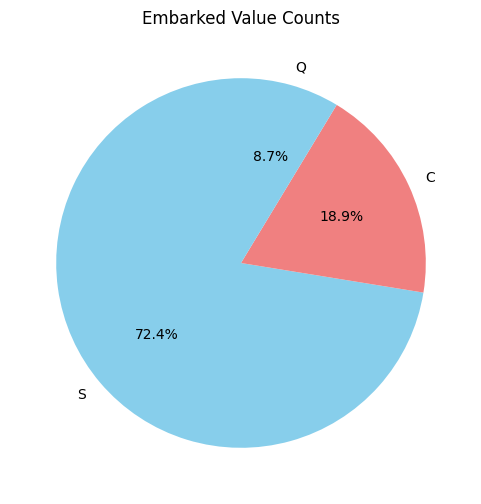

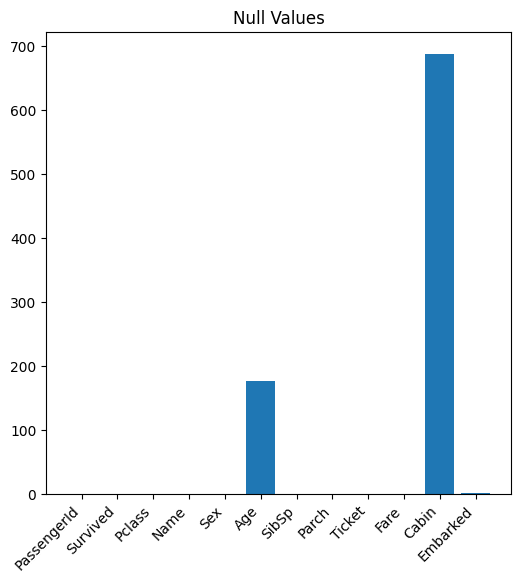

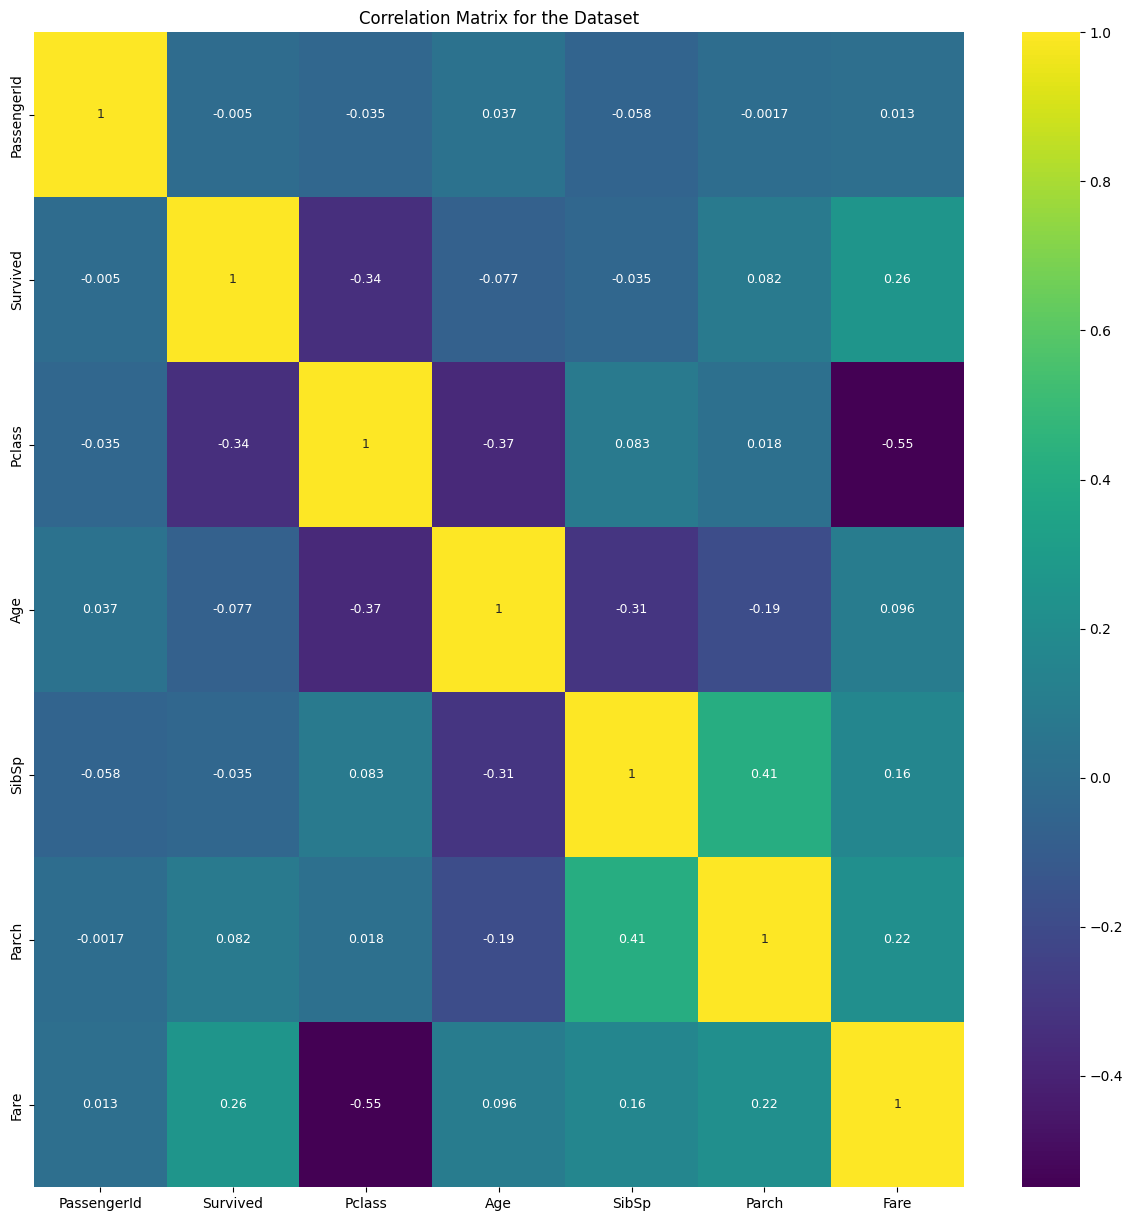

In [2]:
# Stream (required for interrupt to work)
from langchain.messages import HumanMessage, SystemMessage
messages = [SystemMessage(content="dataset address: \"datasets/Titanic-Dataset.csv\""),HumanMessage(content="Analyze the data")]

# Use stream() instead of invoke() to enable input() functionality
for chunk in agent.stream({"messages": messages}, config):
    # Process each chunk as it arrives
    for node_name, node_output in chunk.items():
        print(f"\n[{node_name}]")
        if "messages" in node_output and len(node_output["messages"]) > 0:
            last_message = node_output["messages"][-1]
            if hasattr(last_message, "content") and last_message.content:
                print(f"Content: {last_message.content}")
            if hasattr(last_message, "tool_calls") and last_message.tool_calls:
                print(f"Tool calls: {last_message.tool_calls}")
        else:
            print(f"Output: {node_output}")

In [3]:
messages

[SystemMessage(content='dataset address: "datasets/Titanic-Dataset.csv"', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={})]

In [3]:
from langgraph.types import Command

# config = {"configurable": {"thread_id": "chat-1"}}

# # First run: hits interrupt and pauses
# result = agent.invoke({"input": "hi"}, config=config)
# print(result["__interrupt__"])

# Resume: this continues, and interrupt() returns this value
agent.invoke(Command(resume="drop the entire column"), config=config)



LLM:  The 'Age' column has 177 missing values. I recommend replacing these missing values with the average age. Would you like to proceed with this option, or would you prefer to drop all rows with missing 'Age' values, or drop the 'Age' column entirely?


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 26.14494691s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerMo

In [7]:
for message in messages['messages'][-2:]:
    print(message.content[0]['text'])

---

### **Description of the Data**
The Titanic dataset contains **891 rows** and **12 columns**. It is a classic dataset used for binary classification tasks, where the goal is to predict survival.

- **Label Column:** `Survived` (Binary: 0 = No, 1 = Yes)
- **Data Types:**
    - **Numeric:** `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`
    - **Categorical/Text:** `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`

---

### **Data Imbalance**
The dataset shows a moderate imbalance between the target classes. Approximately **38.4%** of the passengers survived, while **61.6%** did not. While there is a difference, it is not extreme enough to severely hinder standard machine learning models, though techniques like stratified sampling might still be beneficial.

![Label Pie Chart](images/label_pie_chart.png)

---

### **Null Values**
Several columns contain missing information that will require preprocessing:

- **Cabin:** This column has a significantly high number of n

In [13]:
report = messages['messages'][-1].content[0]['text']

In [14]:
with open("report.md","w", encoding="utf-8") as f:
    f.write(report)

In [ ]:
from typing import Literal
from state import MessagesState
from langgraph.types import interrupt
from langgraph.graph import StateGraph, START, END
from preprocessor.config.null_handler import null_handler_config
from preprocessor.model import *
def build_preprocessor_subgraph(config: dict):
    def analysis_node(state):
        recommendations = model.invoke(config.analysis_prompt)
        return {"analysis": recommendations.content}

    def struct_node(state):
        struct_model = small_model.with_structured_output(Options)
        options_dict = struct_model.invoke(config.struct_prompt)
        return {"struct": options_dict.content}

    def ask_user_node(state):
        return interrupt({
            "analysis": state["analysis"],
            "struct": state["struct"]
        })
    def update_dataset(state):
        pass

    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node("analysis", analysis_node)
    graph_builder.add_node("struct", struct_node)
    graph_builder.add_node("interrupt", ask_user_node)
    graph_builder.add_node("update", update_dataset)

    graph_builder.add_edge(START, "analysis")
    graph_builder.add_edge("analysis", "struct")
    graph_builder.add_edge("struct", "interrupt")
    graph_builder.add_edge("interrupt","update")
    graph_builder.add_edge("update", END)
    
    graph = graph_builder.compile()
    return graph
    # from IPython.display import Image, display
    # display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
# build_preprocessor_subgraph(null_handler_config)
